In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [1]:
from tmdc_optics_tools.reference.loader import load_reference

ref = load_reference("WSe2_monolayer", "Vaquero2026")

# Dataset-level metadata
print(ref)
print(f"\nTitle       : {ref.title}")
print(f"DOI           : {ref.doi}")
print(f"Dataset       : {ref.dataset_doi}")
print(f"Measurement   : {ref.spectroscopy}")

ReferenceDataset(material='WSe2_monolayer', source='Vaquero2026', spectroscopy='PL', sweeps={'exciton_density': 7})

Title       : Valley-Controlled Many-Body Exciton Interactions in Monolayer WSe2 Phototransistors
DOI           : 10.1021/acs.nanolett.6c01091
Dataset       : 10.48550/arXiv.2604.08382
Measurement   : PL


In [14]:
nI_sweep = ref["exciton_density"]
print(f"Outer sweep  : {nI_sweep.parameter_name} ({nI_sweep.parameter_unit})")
print(f"Default field: {nI_sweep.default_value} {nI_sweep.parameter_unit}")

for nI_value in nI_sweep.values():
    cond = nI_sweep[nI_value]
    print(f"  nI={nI_value/1e12:+.0f} * 1e12 cm^-2")

Outer sweep  : exciton_density (cm^-2)
Default field: 1000000000000.0 cm^-2
  nI=+0 * 1e12 cm^-2
  nI=+1 * 1e12 cm^-2
  nI=+1 * 1e12 cm^-2
  nI=+2 * 1e12 cm^-2
  nI=+5 * 1e12 cm^-2
  nI=+9 * 1e12 cm^-2
  nI=+13 * 1e12 cm^-2


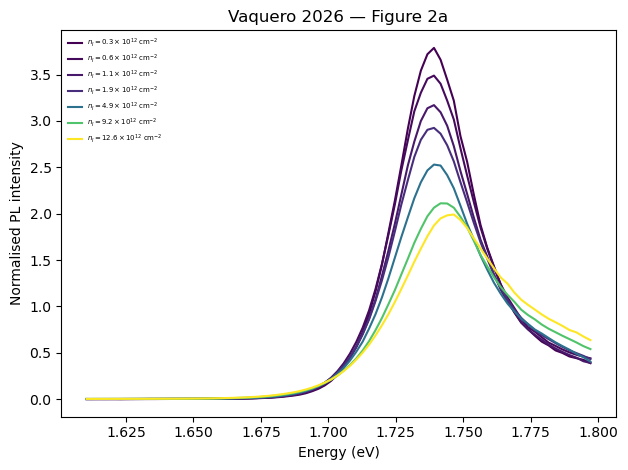

In [28]:
# Reproduce figure 2a from the reference paper

cmap      = sns.color_palette("viridis", as_cmap=True)
norm_cmap = mcolors.Normalize(vmin=min(nI_sweep.values()), vmax=max(nI_sweep.values()))
colors    = {nI: cmap(norm_cmap(nI)) for nI in nI_sweep.values()}

fig, ax = plt.subplots()

for nI_value in nI_sweep.values():
    sp = nI_sweep[nI_value]          # Spectrum directly — no inner sweep
    ax.plot(
        sp.energy,
        sp.intensity,
        color=colors[nI_value],
        linestyle='-',
        label=f'$n_I = {nI_value/1e12:.3g} \\times 10^{{12}}$ cm$^{{-2}}$',
    )

ax.set_xlabel(f'Energy ({sp.energy_unit})')
ax.set_ylabel(f'Normalised {sp.spectroscopy} intensity')
ax.legend(loc='upper left', frameon=False, fontsize=5)
ax.set_title('Vaquero 2026 — Figure 2a')
plt.tight_layout()
plt.show()